# Intro to SnapATAC2 for ATAC-seq standard pipeline analysis

## Part 1: Standard Pipeline Analysis

Followed from tutorial: https://scverse.org/SnapATAC2/tutorials/pbmc.html

In [18]:
#! pip install nbformat>=4.2.0
#! pip install umap-learn
#import sys
#!{sys.executable} -m pip install scanpy
#!{sys.executable} -m pip install umap-learn
#import umap
#!{sys.executable} -m pip install magic-impute
#! pip install ipywidgets
import numpy as np

In [1]:
import platform
import snapatac2 as snap
import os
from umap.umap_ import UMAP

print(platform.machine())
print(snap.__version__)

/users/k25055720/.conda/envs/snapatac_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


x86_64
2.8.0


In [2]:
# Input fragment files
fragment_file = '/users/k25055720/GSM4594389_Female_pit_2_fragments.tsv.gz'
print(os.path.exists(fragment_file))
#print(os.getcwd())

True


### Preprocessing

In [8]:
%%time
data = snap.pp.import_fragments(
    fragment_file,
    chrom_sizes=snap.genome.mm10,
    file="/users/k25055720/pituitary_snapATAC.h5ad",
    min_num_fragments=500,
    sorted_by_barcode=False,
)
data

CPU times: user 12min 40s, sys: 30.2 s, total: 13min 10s
Wall time: 9min 51s


AnnData object with n_obs x n_vars = 63246 x 0 backed at '/users/k25055720/pituitary.h5ad'
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

In [3]:
# Make sure the h5ad file saves itself properly
#data.close()
# Or load the data back in 
data = snap.read("/users/k25055720/pituitary_snapATAC.h5ad")

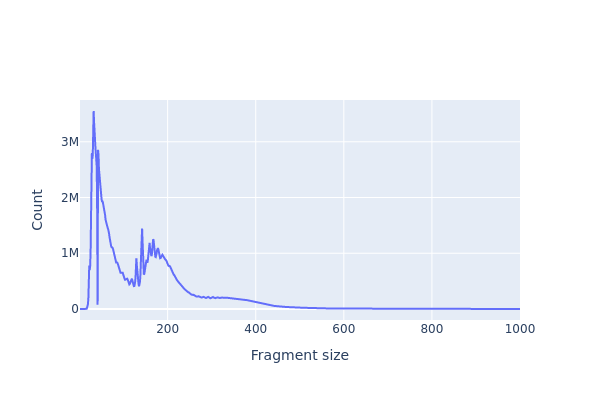

In [12]:
# Visualise fragments
snap.pl.frag_size_distr(data, interactive=False)

In [13]:
fig = snap.pl.frag_size_distr(data, show=False)
fig.update_yaxes(type="log")
#fig.show()

snap.pl.frag_size_distr(data, out_file="/users/k25055720/snapATAC_practice/fragment_dist.html", show=False)

In [14]:
%%time
snap.metrics.tsse(data, snap.genome.mm10)

CPU times: user 1min 56s, sys: 9.64 s, total: 2min 6s
Wall time: 49.9 s


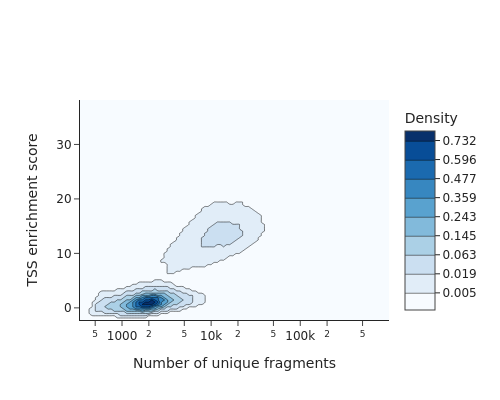

In [15]:
snap.pl.tsse(data, interactive=False)

In [16]:
%%time
snap.pp.filter_cells(data, min_counts=5000, min_tsse=10, max_counts=100000)
data

CPU times: user 39.9 s, sys: 3.62 s, total: 43.5 s
Wall time: 43.3 s


AnnData object with n_obs x n_vars = 7394 x 0 backed at '/users/k25055720/pituitary_snapATAC.h5ad'
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'frac_overlap_TSS', 'TSS_profile', 'frag_size_distr', 'reference_sequences', 'library_tsse'
    obsm: 'fragment_paired'

In [17]:
%%time
snap.pp.add_tile_matrix(data)

CPU times: user 1min 7s, sys: 4.12 s, total: 1min 11s
Wall time: 40 s


In [18]:
snap.pp.select_features(data, n_features=250000)

2026-01-22 10:57:07 - INFO - Selected 250000 features.


### Doublet Removal

In [19]:
%%time
snap.pp.scrublet(data)

2026-01-22 10:57:22 - INFO - Simulating doublets...
2026-01-22 10:57:23 - INFO - Spectral embedding ...
2026-01-22 10:58:54 - INFO - Calculating doublet scores...


CPU times: user 2min 35s, sys: 20.7 s, total: 2min 56s
Wall time: 1min 51s


In [20]:
snap.pp.filter_doublets(data)
data

2026-01-22 10:59:12 - INFO - Detected doublet rate = 6.438%


AnnData object with n_obs x n_vars = 6918 x 5267565 backed at '/users/k25055720/pituitary_snapATAC.h5ad'
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score'
    var: 'count', 'selected'
    uns: 'frac_overlap_TSS', 'TSS_profile', 'doublet_rate', 'scrublet_sim_doublet_score', 'frag_size_distr', 'reference_sequences', 'library_tsse'
    obsm: 'fragment_paired'

### Dimension Reduction

In [21]:
%%time
snap.tl.spectral(data)

CPU times: user 37 s, sys: 1.65 s, total: 38.6 s
Wall time: 37.9 s


In [9]:
%%time
snap.tl.umap(data)

/users/k25055720/.conda/envs/snapatac_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 27 s, sys: 135 ms, total: 27.2 s
Wall time: 25.6 s


### Clustering Analysis

In [10]:
%%time
snap.pp.knn(data)
snap.tl.leiden(data)

CPU times: user 1.36 s, sys: 92.2 ms, total: 1.46 s
Wall time: 1.47 s


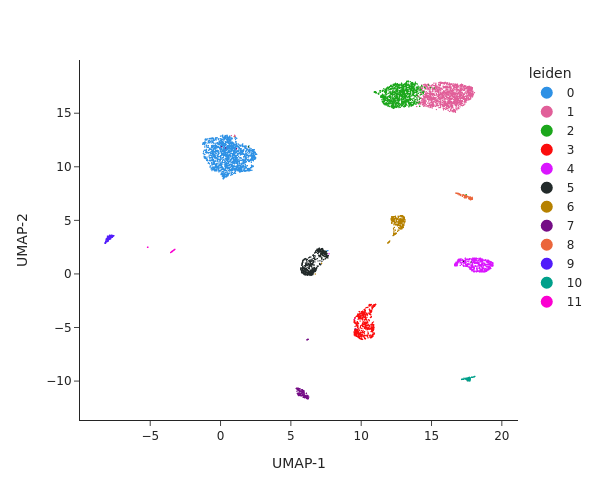

In [30]:
snap.pl.umap(data, color='leiden', interactive=False, height=500)

In [14]:
snap.pl.umap(data, color='leiden', show=False, out_file="snapATAC_practice/umap.pdf", height=500)
snap.pl.umap(data, color='leiden', show=False, out_file="snapATAC_practice/umap.html", height=500)

### Cell Cluster Annotation

In [4]:
%%time
gene_matrix = snap.pp.make_gene_matrix(data, snap.genome.mm10)
gene_matrix

/users/k25055720/.conda/envs/snapatac_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


CPU times: user 1min 37s, sys: 8.04 s, total: 1min 45s
Wall time: 40.9 s


AnnData object with n_obs × n_vars = 6918 × 55291
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden'

### Imputation

In [5]:
import scanpy as sc

sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)

In [6]:
%%time
sc.external.pp.magic(gene_matrix, solver="approximate")

CPU times: user 29.2 s, sys: 1.17 s, total: 30.4 s
Wall time: 19.3 s


In [7]:
# Copy over UMAP embedding
gene_matrix.obsm["X_umap"] = data.obsm["X_umap"]

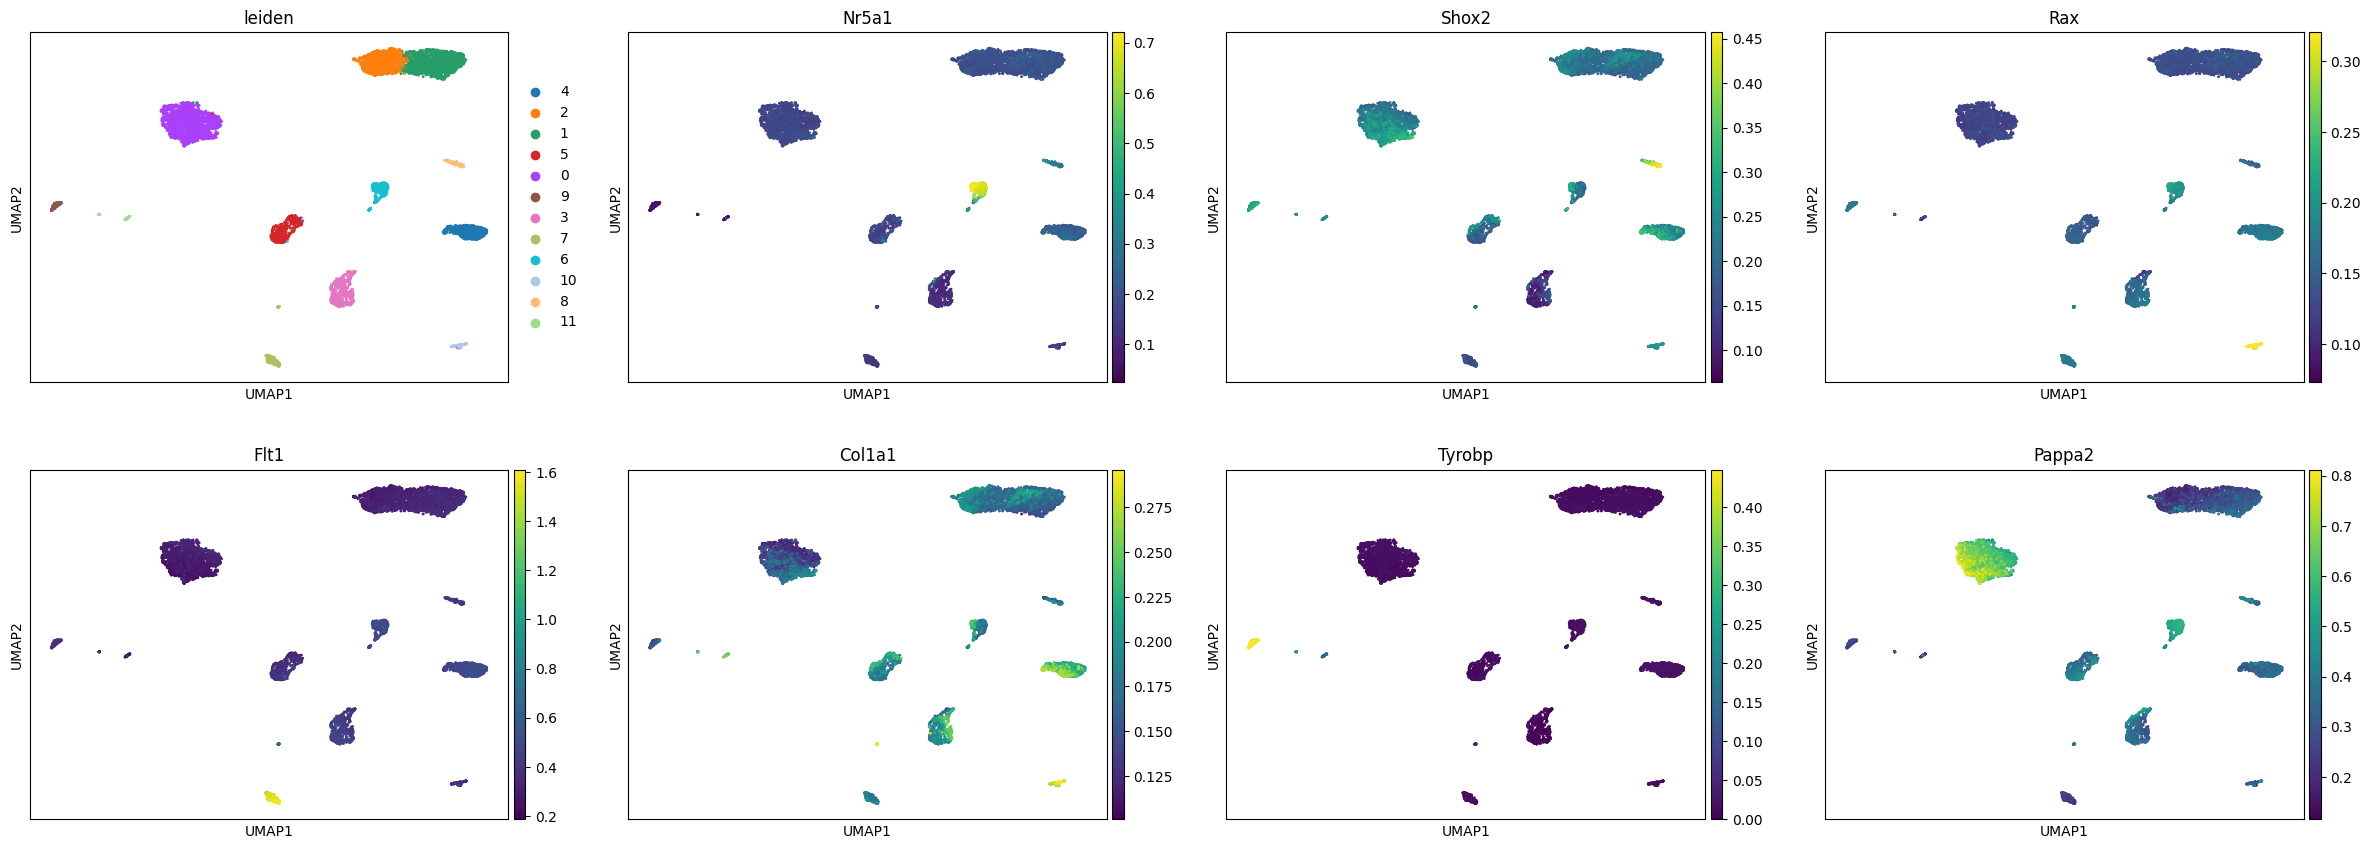

In [8]:
# Select marker genes
marker_genes = ['Nr5a1', 'Shox2', 'Rax', 'Flt1', 'Col1a1', 'Tyrobp', 'Pappa2']
sc.pl.umap(gene_matrix, use_raw=False, color=["leiden"] + marker_genes)

In [17]:
# Save file 

sc.settings.figdir = "snapATAC_practice"

sc.pl.umap(
    gene_matrix, 
    use_raw=False, 
    color=["leiden"] + marker_genes,
    show=False,
    save="umap_with_genes.pdf" 
)

/users/k25055720/.conda/envs/snapatac_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1267: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


[<Axes: title={'center': 'leiden'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Nr5a1'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Shox2'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Rax'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Flt1'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Col1a1'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Tyrobp'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Pappa2'}, xlabel='UMAP1', ylabel='UMAP2'>]

In [14]:
data.close()

## Part 2: Annotating Cell Clusters

This part is off-script, not following the tutorial because theirs uses RNA-seq data

In [9]:
# Transfer cluster information from data into the gene matrix
gene_matrix.obs['leiden'] = data.obs['leiden']

/tmp/ipykernel_1765248/1476098646.py:2: DeprecationWarning: `_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'
  gene_matrix.obs['leiden'] = data.obs['leiden']


In [10]:
# Define markers
markers = {
    "stem_cells": ["Sox2", "Rbpms", "Mia", "Aqp3", "Krt8", "Krt18", "Lcn2", "Cyp2f2", "Aldh1a2", "Folr1", "Pla2g7", "Aldoc", "Mgst1", "Glul"],
    "somatotrophs": ["Pappa2", "Car10", "Rxrg", "Gh", "Ghrhr"],
    "lactotrophs": ["Prl", "Hepacam2", "Edil3", "Angpt1", "Olfm1", "Six6"],
    "thyrotroph": ["Shox2", "Dio2", "Ttr", "Rbp4", "Trhr", "Tshb"],
    "corticotrophs": ["Pomc", "Crhr1", "Tbx19", "Gpc5", "Tnt1", "Atp1a2"],
    "melanotrophs": ["Pomc", "Tbx19", "Pax7", "Oacyl", "Pcsk2", "Pkib", "Megf11", "Esm1", "Etv1", "Ascl1", "Sparcl1"],
    "gonadotrophs": ["Nr5a1", "Fshb", "Spp1", "Tgfbr3l", "Gnrhr"],
    "pituicytes": ["Fgf10", "Rax", "Scn7a", "Gpc3", "Nkx2-1"],
    "endothelial_cells": ["Pecam1", "Plvap", "Igfbp7", "Igfbp3", "Emcn", "Flt1"],
    "mesenchymal_cells": ["Col1a1", "Pdgfra", "Ogn", "Dcn", "Inmt", "Lum"],
    "immune_cells": ["Cd4", "Tyrobp", "Cd14", "Trbc2", "Cd68", "C1qa", "C1qc", "Lyz2"],
    "erythrocytes": ["Hba-a1", "Hba-a2", "Hba-x"]
}

... storing 'leiden' as categorical


/users/k25055720/.conda/envs/snapatac_env/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 51890 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


categories: 0, 1, 2, etc.
var_group_labels: stem_cells, somatotrophs, lactotrophs, etc.


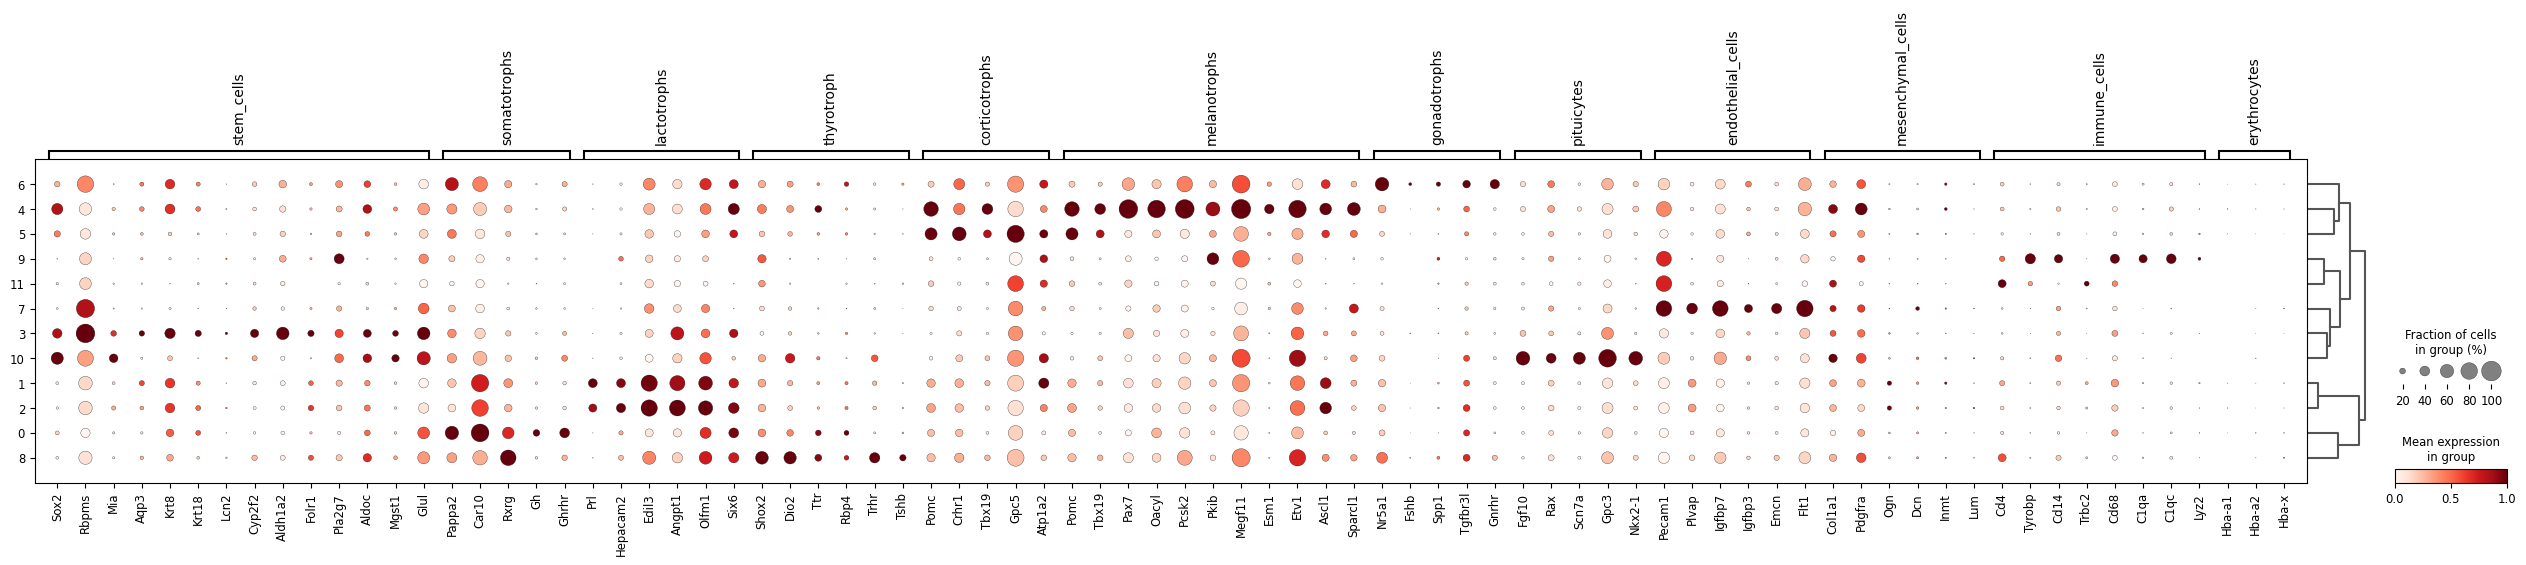

In [11]:
# Plot the DotPlot
available_markers = {
    group: [gene for gene in genes if gene in gene_matrix.var_names]
    for group, genes in markers.items()
}

sc.settings.figdir = "snapATAC_practice"

# Now plot using the cleaned dictionary
sc.pl.dotplot(
    gene_matrix, 
    available_markers, 
    groupby='leiden', 
    standard_scale='var',
    dendrogram=True
    #save="_marker_genes.pdf"
)

In [29]:
# Name clusters
cluster_map = {
    "0": "somatotrophs",
    "1": "lactotrophs",
    "2": "lactotrophs",
    "3": "stem_cells",
    "4": "melanotrophs",
    "5": "corticotrophs",
    "6": "gonadotrophs",
    "7": "endothelial_cells",
    "8": "thyrotroph",
    "9": "immune_cells",
    "10": "pituicytes",
    "11": "mesenchymal_cells"
}

In [30]:
import pandas as pd

#Add data to object and plot UMAP
mapped_labels = pd.Series(data.obs['leiden']).map(cluster_map).values

# Assign it back to BOTH objects
data.obs['cell_type'] = mapped_labels
gene_matrix.obs['cell_type'] = mapped_labels

/tmp/ipykernel_1765248/2501587027.py:4: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



... storing 'cell_type' as categorical


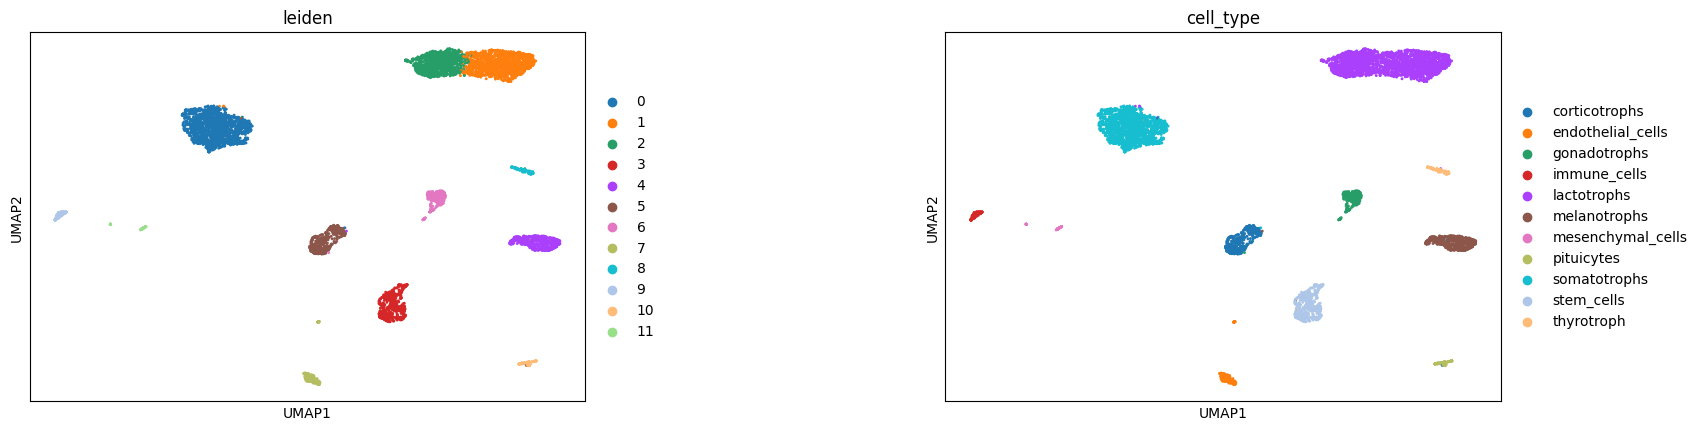

In [31]:
sc.pl.umap(gene_matrix, color=['leiden', 'cell_type'], wspace=0.5)

In [32]:
data.close()

### Part 3: Identify Differentially Accessible Regions

Tutorial from https://scverse.org/SnapATAC2/version/2.6/tutorials/diff.html

In [4]:
import polars as pl

snap.__version__

'2.8.0'

In [20]:
data = snap.read("/users/k25055720/pituitary_snapATAC.h5ad")
#data.close()

In [5]:
# Peak calling at cluster-level
# No need to repeat this if data.close() has been done after
#%%time
snap.tl.macs3(data, groupby='cell_type')
# Data from this is stored as data.uns['macs3'] where the keys are the cell type labels and values are identified peaks stores as a df object

2026-02-04 14:16:33 - INFO - Exporting fragments...
2026-02-04 14:17:34 - INFO - Calling peaks...
100%|██████████| 11/11 [11:23<00:00, 62.17s/it]


In [23]:
# The above usually generates overlapping peaks, merging the peaks below fixes this inconsistency. 
#%%time
#peaks = snap.tl.merge_peaks(data.uns['macs3'], snap.genome.mm10)
#peaks.head()
data.uns['peaks'].head()

RuntimeError: No such key: peaks

In [7]:
# With this, make a peak matrix 
#%%time
peak_mat = snap.pp.make_peak_matrix(data, use_rep=peaks['Peaks'])
peak_mat

/users/k25055720/.conda/envs/snapatac_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 6918 × 296949
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'cell_type'

In [8]:
marker_peaks = snap.tl.marker_regions(peak_mat, groupby='cell_type', pvalue=0.01)

2026-02-04 14:29:37 - WARNING - Input contains 87827 peaks, only 50000 peaks will be plotted.


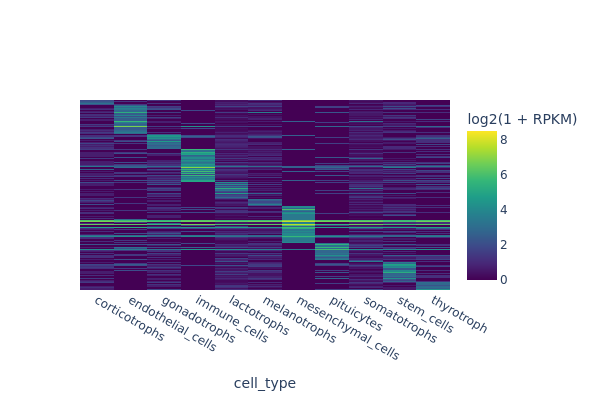

In [9]:
snap.pl.regions(peak_mat, groupby='cell_type', peaks=marker_peaks, interactive=False)

In [10]:
#data.close()

In [12]:
# This is gonna take hours. CPU says >3hrs
#%%time
motifs = snap.tl.motif_enrichment(
    motifs=snap.datasets.cis_bp(unique=True),
    regions=marker_peaks,
    genome_fasta=snap.genome.mm10,
)

2026-02-04 14:29:57 - INFO - Fetching 87827 sequences ...
100%|███████████████████████████████████████| 774M/774M [00:00<00:00, 2.00TB/s]
Decompressing '/users/k25055720/.cache/snapatac2/gencode_vM25_GRCm38.fa.gz' to '/users/k25055720/.cache/snapatac2/gencode_vM25_GRCm38.fa.gz.decomp' using method 'gzip'.
2026-02-04 14:31:18 - INFO - Computing enrichment ...
100%|██████████| 1165/1165 [30:12<00:00,  1.56s/it]


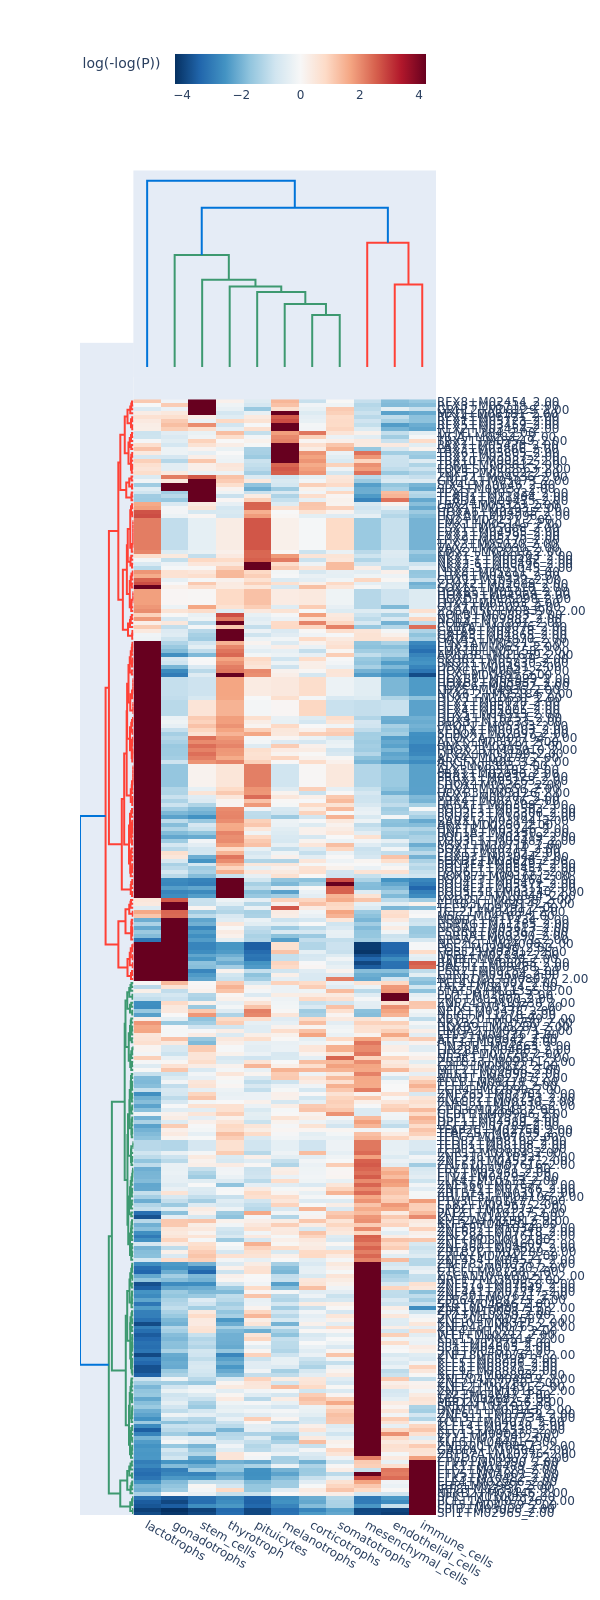

In [14]:
# Visualise output
snap.pl.motif_enrichment(motifs, max_fdr=0.0001, height=1600, interactive=False)

## Regression-based differential test

The tl.marker_regions don't consider the variations across the cells. 
To use this single-cell information, we apply a regression-based differential test.

Select peaks that are present

In [16]:
# Find out the cell_types present
data.obs['cell_type'].unique()

# Select for somatotrophs vs corticotrophs in this workflow

/tmp/ipykernel_3021266/1966585921.py:2: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



cell_type
str
"""corticotrophs"""
"""gonadotrophs"""
"""somatotrophs"""
"""thyrotroph"""
"""mesenchymal_cells"""
…
"""immune_cells"""
"""lactotrophs"""
"""endothelial_cells"""


### Select two cell groups - compare peaks between them

In [25]:
group1 = "somatotrophs"
group2 = "corticotrophs"
somato_cells = data.obs['cell_type'] == group1
cortico_cells = data.obs['cell_type'] == group2
peaks_selected = np.logical_or(
    peaks[group1].to_numpy(),
    peaks[group2].to_numpy(),
)

/tmp/ipykernel_3021266/3140775001.py:3: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_3021266/3140775001.py:4: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



In [26]:
# Perform the differential test
diff_peaks = snap.tl.diff_test(
    peak_mat,
    cell_group1=somato_cells,
    cell_group2=cortico_cells,
    features=peaks_selected,
)

2026-02-04 15:21:28 - INFO - Input contains 120011 features, now perform filtering with 'min_log_fc = 0.25' and 'min_pct = 0.05' ...
2026-02-04 15:21:38 - INFO - Testing 24317 features ...
100%|██████████| 24317/24317 [06:14<00:00, 65.00it/s]


In [27]:
# Filter based on an adjusted p-value (in this case, padj<0.01)
diff_peaks = diff_peaks.filter(pl.col('adjusted p-value') < 0.01)
diff_peaks.head()

feature name,log2(fold_change),p-value,adjusted p-value
str,f64,f64,f64
"""chr4:46422564-46423065""",-8.999577,7.7494e-79,9.4221e-75
"""chr4:133614374-133614875""",-4.111185,6.9846e-79,9.4221e-75
"""chr12:3954770-3955271""",-5.119272,4.7634e-75,3.8610e-71
"""chr8:11803032-11803533""",-6.57887,1.3302e-67,8.0865e-64
"""chr11:103685125-103685626""",-5.125893,3.6128e-66,1.7571e-62


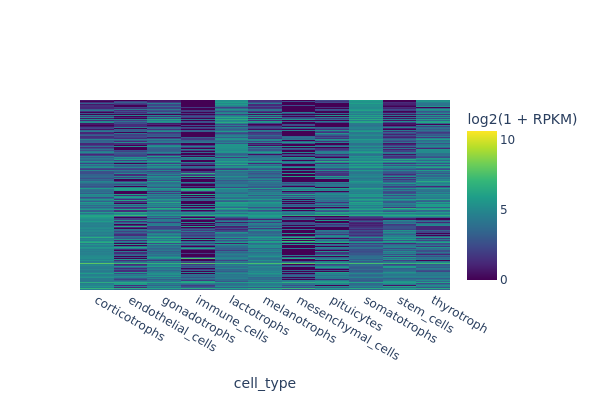

In [29]:
# Plot it!
snap.pl.regions(
    peak_mat,
    groupby = 'cell_type',
    peaks = {
        group1: diff_peaks.filter(pl.col("log2(fold_change)") > 0)['feature name'].to_numpy(),
        group2: diff_peaks.filter(pl.col("log2(fold_change)") < 0)['feature name'].to_numpy(),
    },
    interactive = False,
)

### Select one cell type - compare to the rest of the cells

This selects random cells from each cluster to form the background, then performs a test between the chosen cell and the background.

Here, the code selects 30 cells from other cell clusters, then sets the direction positive because we are interested in peaks that are more accessible in memory B cells. 

In [30]:
# Uses group2 from above (corticotrophs)

barcodes = np.array(data.obs_names)
background = []
for i in np.unique(data.obs['cell_type']):
    if i != group2:
        cells = np.random.choice(barcodes[data.obs['cell_type'] == i], size=30, replace=False)
        background.append(cells)
background = np.concatenate(background)

/tmp/ipykernel_3021266/622112545.py:5: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_3021266/622112545.py:7: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



In [32]:
diff_peaks = snap.tl.diff_test(
    peak_mat,
    cell_group1=cortico_cells,
    cell_group2=background,
    features=peaks[group2].to_numpy(),
    direction="positive",
)

2026-02-04 15:28:27 - INFO - Input contains 76133 features, now perform filtering with 'min_log_fc = 0.25' and 'min_pct = 0.05' ...
2026-02-04 15:28:34 - INFO - Testing 15225 features ...
100%|██████████| 15225/15225 [02:58<00:00, 85.51it/s]


In [33]:
diff_peaks = diff_peaks.filter(pl.col('adjusted p-value') < 0.01)
diff_peaks.head()

feature name,log2(fold_change),p-value,adjusted p-value
str,f64,f64,f64
"""chr9:56832860-56833361""",3.28516,5.2266e-22,7.9575e-18
"""chr9:117153733-117154234""",3.131176,1.4220e-21,1.0825e-17
"""chr1:75488531-75489032""",3.745285,1.4836e-19,7.5292e-16
"""chr17:34670222-34670723""",2.893677,1.2839e-18,4.8869e-15
"""chr12:3954770-3955271""",2.480939,2.9325e-18,7.4411e-15


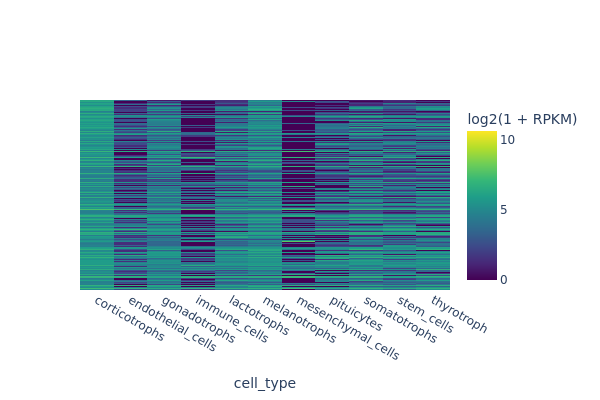

In [34]:
snap.pl.regions(
    peak_mat,
    groupby='cell_type',
    peaks={ group2: diff_peaks['feature name'].to_numpy() },
    interactive=False,
)

In [35]:
data.close()